# LSTM: Trajektorie lernen → danach Wurf klassifizieren (clean & noisy)

Zielsetzung:
- Das LSTM lernt die Trajektorie \((x(t), y(t))\) aus Eingaben `[theta, v0, hs, t]`.
- Nach dem Training wird jede vorhergesagte Trajektorie je `wurf_id` deterministisch klassifiziert:
  `0=zu kurz`, `1=Treffer`, `2=zu lang`.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Datensatz vs. Vorhersage), wurfweise Konfusionsmatrix & Metriken, Vergleichstabelle.

Klassifikations-Heuristik:
Am Korb-Plane `x = l`: Falls `max(x_pred) < l` ⇒ zu kurz. Sonst `y_pred` an `x=l` linear interpolieren.
Wenn `hKorb - (Rr - Rb) ≤ y_pred(l) ≤ hKorb + (Rr - Rb)` ⇒ Treffer, sonst zu lang.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [22]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25*hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g/(2*(l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx=v0*np.cos(theta); vy=v0*np.sin(theta)
        x = vx*t; y = vy*t - 0.5*g*t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise: df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2*v0*np.sin(theta)/g; t = np.linspace(0, T, 50)
            x,y = self.wurftrajektorien(theta, v0, t)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x,y,t):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


In [23]:
def df_to_pointwise_tensors_with_cls(df, hs_val=2.13, device="cpu"):
    d = df.copy()

    # t berechnen, falls noch nicht vorhanden
    if "t" not in d.columns:
        d["vx"] = d["v0"] * np.cos(d["theta"])
        d["vx"] = d["vx"].replace(0, 1e-8)
        d["t"] = d["x"] / d["vx"]

    d["t"] = d["t"].clip(lower=0.0)
    d["hs"] = hs_val

    d = d.dropna(subset=["theta", "v0", "t", "x", "y", "label", "wurf_id"])

    X = d[["theta", "v0", "hs", "t"]].values.astype(np.float32)
    Y = d[["x", "y"]].values.astype(np.float32)
    C = d["label"].values.astype(np.int64)  # Klassen 0/1/2
    wids = d["wurf_id"].values  # für spätere Aggregation

    # (N, 4) -> (N, 1, 4) wie bisher
    X_seq = X.reshape(-1, 1, 4)

    Xt = torch.tensor(X_seq, dtype=torch.float32, device=device)
    Yt = torch.tensor(Y, dtype=torch.float32, device=device)
    Ct = torch.tensor(C, dtype=torch.long, device=device)

    return Xt, Yt, Ct, wids, d

In [24]:
class LSTMxyMultiTask(nn.Module):
    def __init__(self, input_size=4, hidden_size=64, num_layers=1, n_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.reg_head = nn.Linear(hidden_size, 2)  # x,y
        self.cls_head = nn.Linear(hidden_size, n_classes)  # Klassenlogits

    def forward(self, x):
        # x: (N, 1, 4) – Sequenzlänge = 1 (punktweise Setup)
        out, _ = self.lstm(x)
        h = out[:, -1, :]  # (N, hidden)
        xy = self.reg_head(h)  # (N, 2)
        logits = self.cls_head(h)  # (N, n_classes)
        return xy, logits

In [25]:
def train_multitask_full(
    model,
    train_loader,
    n_epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    lambda_cls=1.0,
    device="cpu",
):
    model.to(device)
    opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    mse_loss = nn.MSELoss()
    ce_loss = nn.CrossEntropyLoss()

    history = {
        "train_reg_loss": [],
        "train_cls_loss": [],
        "train_total_loss": [],
    }

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_reg = 0.0
        total_cls = 0.0
        total_all = 0.0
        n_samples = 0

        for xb, yb_reg, yb_cls in train_loader:
            xb = xb.to(device)
            yb_reg = yb_reg.to(device)
            yb_cls = yb_cls.to(device)

            opt.zero_grad()

            pred_xy, logits = model(xb)

            loss_reg = mse_loss(pred_xy, yb_reg)
            loss_cls = ce_loss(logits, yb_cls)
            loss = loss_reg + lambda_cls * loss_cls

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            bs = xb.size(0)
            total_reg += loss_reg.item() * bs
            total_cls += loss_cls.item() * bs
            total_all += loss.item() * bs
            n_samples += bs

        mean_reg = total_reg / n_samples
        mean_cls = total_cls / n_samples
        mean_all = total_all / n_samples

        history["train_reg_loss"].append(mean_reg)
        history["train_cls_loss"].append(mean_cls)
        history["train_total_loss"].append(mean_all)

        if (epoch <= 5) or (epoch % 10 == 0):
            print(
                f"Epoch {epoch:03d} | "
                f"reg={mean_reg:.6f}  cls={mean_cls:.6f}  total={mean_all:.6f}"
            )

    return model, history

In [26]:
def predict_pointwise_with_cls(model, loader, wids_all, y_true_all, device="cpu"):
    model.eval()
    preds_xy = []
    preds_logits = []

    with torch.no_grad():
        for xb, yb_reg, yb_cls in loader:
            xb = xb.to(device)
            pred_xy, logits = model(xb)

            preds_xy.append(pred_xy.cpu().numpy())
            preds_logits.append(logits.cpu().numpy())

    preds_xy = np.concatenate(preds_xy, axis=0)
    preds_logits = np.concatenate(preds_logits, axis=0)

    df_pred = pd.DataFrame(
        {
            "wurf_id": wids_all,
            "true_class": y_true_all,
            "pred_x": preds_xy[:, 0],
            "pred_y": preds_xy[:, 1],
            "logit_0": preds_logits[:, 0],
            "logit_1": preds_logits[:, 1],
            "logit_2": preds_logits[:, 2],
        }
    )
    return df_pred

In [27]:
def build_throw_level_predictions(df_pred):
    grouped = df_pred.groupby("wurf_id")

    throw_ids = []
    y_true = []
    y_pred = []

    for wid, g in grouped:
        mean_logits = g[["logit_0", "logit_1", "logit_2"]].mean(axis=0).values
        pred_cls = int(np.argmax(mean_logits))
        true_cls = int(g["label"].iloc[0])

        throw_ids.append(wid)
        y_true.append(true_cls)
        y_pred.append(pred_cls)

    return np.array(throw_ids), np.array(y_true), np.array(y_pred)


def evaluate_throw_level_cls(df_pred):
    wids, y_true, y_pred = build_throw_level_predictions(df_pred)
    print("Classification report (throw level):")
    print(classification_report(y_true, y_pred, labels=[0, 1, 2]))


## Clean‑Training → Wurfklassifikation

Epoch 001 | reg=7.932137  cls=1.096261  total=8.480268
Epoch 002 | reg=2.906686  cls=1.094303  total=3.453838
Epoch 003 | reg=0.899908  cls=1.092864  total=1.446340
Epoch 004 | reg=0.815783  cls=1.086040  total=1.358803
Epoch 005 | reg=0.648115  cls=1.072008  total=1.184119
Epoch 010 | reg=0.090645  cls=0.901434  total=0.541362
Epoch 020 | reg=0.066411  cls=0.415334  total=0.274079
Epoch 030 | reg=0.031230  cls=0.204237  total=0.133349
Epoch 040 | reg=0.009441  cls=0.108705  total=0.063794
Epoch 050 | reg=0.004792  cls=0.063687  total=0.036635
Epoch 060 | reg=0.002964  cls=0.040766  total=0.023347
Epoch 070 | reg=0.002127  cls=0.027552  total=0.015903
Epoch 080 | reg=0.001680  cls=0.019727  total=0.011543
Epoch 090 | reg=0.001347  cls=0.014563  total=0.008628
Epoch 100 | reg=0.001129  cls=0.011069  total=0.006664
Epoch 110 | reg=0.000988  cls=0.008533  total=0.005254
Epoch 120 | reg=0.000881  cls=0.006741  total=0.004252
Epoch 130 | reg=0.000817  cls=0.005337  total=0.003486
Epoch 140 

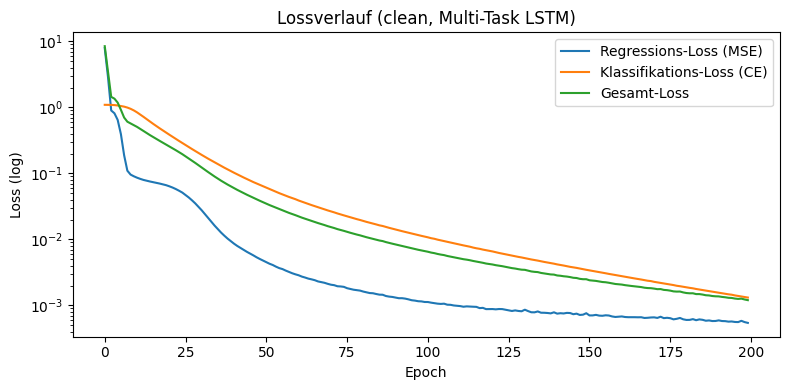

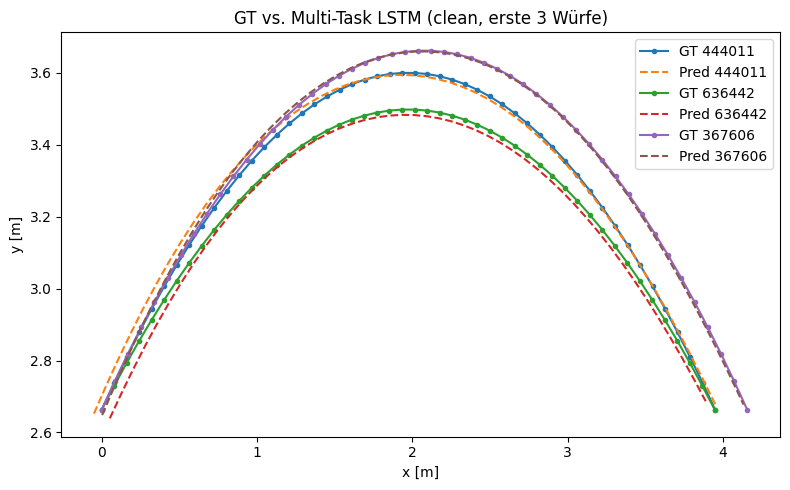

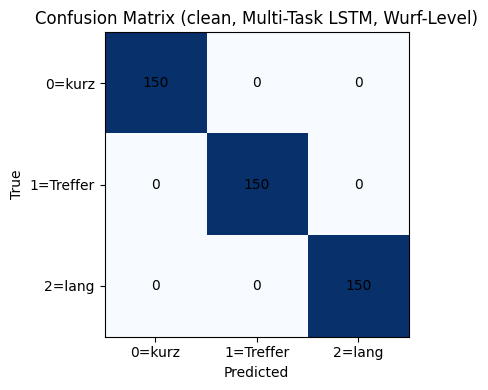

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sim = DataGen(hs=2.13)
params = (
    sim.params
    if hasattr(sim, "params")
    else {"l": 4.115, "hKorb": 3.048, "Rr": 0.2286, "Rb": 0.1219}
)

df_clean = sim.generate_dataset(n=150, with_noise=False)

Xt, Yt, Ct, wids, dproc = df_to_pointwise_tensors_with_cls(
    df_clean, hs_val=2.13, device=device
)
full_ds = TensorDataset(Xt, Yt, Ct)
train_loader = DataLoader(full_ds, batch_size=512, shuffle=True)
eval_loader = DataLoader(full_ds, batch_size=512, shuffle=False)

model = LSTMxyMultiTask(input_size=4, hidden_size=64, num_layers=1, n_classes=3)
model, hist = train_multitask_full(
    model,
    train_loader,
    n_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    lambda_cls=0.5,
    device=device,
)       
plt.figure(figsize=(8, 4))
plt.plot(hist["train_reg_loss"], label="Regressions-Loss (MSE)")
plt.plot(hist["train_cls_loss"], label="Klassifikations-Loss (CE)")
plt.plot(hist["train_total_loss"], label="Gesamt-Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Lossverlauf (clean, Multi-Task LSTM)")
plt.legend()
plt.tight_layout()

model.eval()
pred_xy_list = []
logits_list = []

with torch.no_grad():
    for xb, yb_reg, yb_cls in eval_loader:
        xb = xb.to(device)
        pred_xy, logits = model(xb)
        pred_xy_list.append(pred_xy.cpu().numpy())
        logits_list.append(logits.cpu().numpy())

pred_xy = np.concatenate(pred_xy_list, axis=0)
logits = np.concatenate(logits_list, axis=0)

# DataFrame mit Vorhersagen zusammenbauen
dproc_pred = dproc.copy()
dproc_pred["x_pred"] = pred_xy[:, 0]
dproc_pred["y_pred"] = pred_xy[:, 1]
dproc_pred["logit_0"] = logits[:, 0]
dproc_pred["logit_1"] = logits[:, 1]
dproc_pred["logit_2"] = logits[:, 2]

# ---------------------------------------------------------
# 5a) Plot: GT vs. vorhergesagte Trajektorien für ein paar Würfe
# ---------------------------------------------------------

ids = dproc_pred["wurf_id"].unique()[:3]

plt.figure(figsize=(8, 5))
for wid in ids:
    g_gt = dproc[dproc["wurf_id"] == wid].sort_values("t")
    g_pr = dproc_pred[dproc_pred["wurf_id"] == wid].sort_values("t")
    plt.plot(g_gt["x"], g_gt["y"], marker=".", label=f"GT {wid[:6]}")
    plt.plot(g_pr["x_pred"], g_pr["y_pred"], linestyle="--", label=f"Pred {wid[:6]}")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("GT vs. Multi-Task LSTM (clean, erste 3 Würfe)")
plt.legend()
plt.tight_layout()

wids_throw, y_true_throw, y_pred_throw = build_throw_level_predictions(dproc_pred)

cm = confusion_matrix(y_true_throw, y_pred_throw, labels=[0, 1, 2])
print("Classification report (throw level, clean, Multi-Task LSTM):")
print(classification_report(y_true_throw, y_pred_throw, labels=[0, 1, 2]))

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (clean, Multi-Task LSTM, Wurf-Level)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1, 2], ["0=kurz", "1=Treffer", "2=lang"])
plt.yticks([0, 1, 2], ["0=kurz", "1=Treffer", "2=lang"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()

## Noisy‑Training → Wurfklassifikation

Epoch 001 | reg=6.996855  cls=1.096009  total=7.544859
Epoch 002 | reg=2.474931  cls=1.093579  total=3.021721
Epoch 003 | reg=0.901056  cls=1.091854  total=1.446983
Epoch 004 | reg=0.798423  cls=1.085348  total=1.341097
Epoch 005 | reg=0.639784  cls=1.074925  total=1.177246
Epoch 010 | reg=0.103257  cls=0.963166  total=0.584840
Epoch 020 | reg=0.074255  cls=0.488358  total=0.318434
Epoch 030 | reg=0.040565  cls=0.242800  total=0.161965
Epoch 040 | reg=0.018544  cls=0.127587  total=0.082337
Epoch 050 | reg=0.014112  cls=0.074232  total=0.051228
Epoch 060 | reg=0.012757  cls=0.047483  total=0.036498
Epoch 070 | reg=0.012131  cls=0.032569  total=0.028415
Epoch 080 | reg=0.011702  cls=0.023675  total=0.023539
Epoch 090 | reg=0.011346  cls=0.017853  total=0.020273
Epoch 100 | reg=0.011181  cls=0.013910  total=0.018136
Epoch 110 | reg=0.011109  cls=0.010990  total=0.016604
Epoch 120 | reg=0.010924  cls=0.008913  total=0.015380
Epoch 130 | reg=0.010976  cls=0.007215  total=0.014584
Epoch 140 

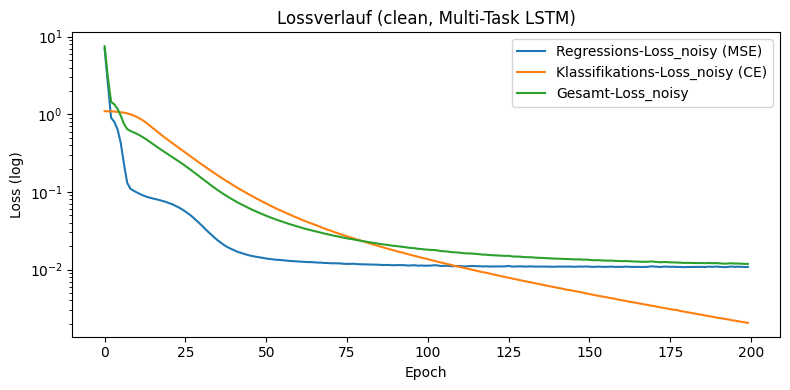

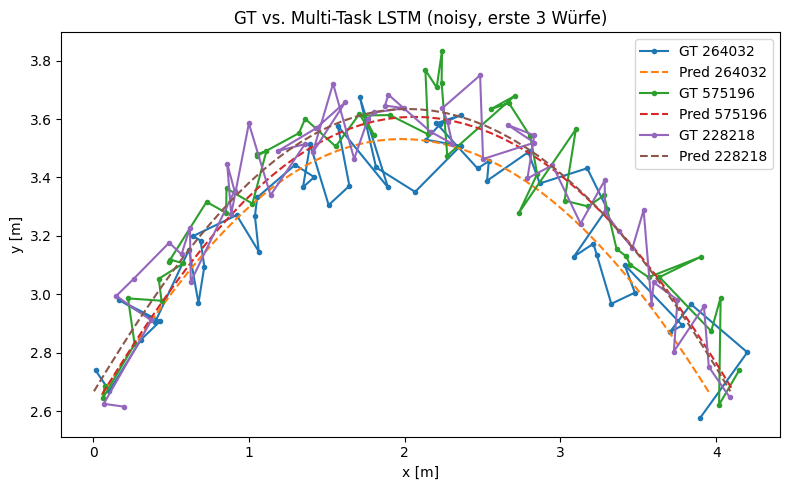

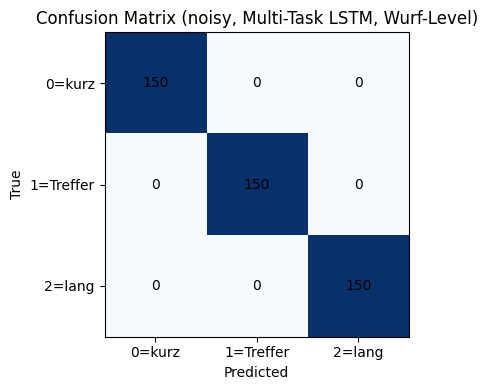

In [29]:
df_noisy = sim.generate_dataset(n=150, with_noise=True)

Xt_noisy, Yt_noisy, Ct_noisy, wids_noisy, dproc_noisy = (
    df_to_pointwise_tensors_with_cls(df_noisy, hs_val=2.13, device=device)
)
full_ds_noisy = TensorDataset(Xt_noisy, Yt_noisy, Ct_noisy)
train_loader_noisy = DataLoader(full_ds_noisy, batch_size=512, shuffle=True)
eval_loader_noisy = DataLoader(full_ds_noisy, batch_size=512, shuffle=False)

model_noisy = LSTMxyMultiTask(input_size=4, hidden_size=64, num_layers=1, n_classes=3)
model_noisy, hist_noisy = train_multitask_full(
    model_noisy,
    train_loader_noisy,
    n_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    lambda_cls=0.5,
    device=device,
)
plt.figure(figsize=(8, 4))
plt.plot(hist_noisy["train_reg_loss"], label="Regressions-Loss_noisy (MSE)")
plt.plot(hist_noisy["train_cls_loss"], label="Klassifikations-Loss_noisy (CE)")
plt.plot(hist_noisy["train_total_loss"], label="Gesamt-Loss_noisy")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Lossverlauf (clean, Multi-Task LSTM)")
plt.legend()
plt.tight_layout()

model_noisy.eval()
pred_xy_list_noisy = []
logits_list_noisy = []

with torch.no_grad():
    for xb_noisy, yb_reg_noisy, yb_cls_noisy in eval_loader_noisy:
        xb_noisy = xb_noisy.to(device)
        pred_xy_noisy, logits_noisy = model_noisy(xb_noisy)
        pred_xy_list_noisy.append(pred_xy_noisy.cpu().numpy())
        logits_list_noisy.append(logits_noisy.cpu().numpy())

pred_xy_noisy = np.concatenate(pred_xy_list_noisy, axis=0)
logits_noisy = np.concatenate(logits_list_noisy, axis=0)

# DataFrame mit Vorhersagen zusammenbauen
dproc_pred_noisy = dproc_noisy.copy()
dproc_pred_noisy["x_pred"] = pred_xy_noisy[:, 0]
dproc_pred_noisy["y_pred"] = pred_xy_noisy[:, 1]
dproc_pred_noisy["logit_0"] = logits_noisy[:, 0]
dproc_pred_noisy["logit_1"] = logits_noisy[:, 1]
dproc_pred_noisy["logit_2"] = logits_noisy[:, 2]

# ---------------------------------------------------------
# 5a) Plot: GT vs. vorhergesagte Trajektorien für ein paar Würfe
# ---------------------------------------------------------

ids_noisy = dproc_pred_noisy["wurf_id"].unique()[:3]

plt.figure(figsize=(8, 5))
for wid in ids_noisy:
    g_gt_noisy = dproc_noisy[dproc_noisy["wurf_id"] == wid].sort_values("t")
    g_pr_noisy = dproc_pred_noisy[dproc_pred_noisy["wurf_id"] == wid].sort_values("t")
    plt.plot(g_gt_noisy["x"], g_gt_noisy["y"], marker=".", label=f"GT {wid[:6]}")
    plt.plot(
        g_pr_noisy["x_pred"],
        g_pr_noisy["y_pred"],
        linestyle="--",
        label=f"Pred {wid[:6]}",
    )

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("GT vs. Multi-Task LSTM (noisy, erste 3 Würfe)")
plt.legend()
plt.tight_layout()

wids_throw_noisy, y_true_throw_noisy, y_pred_throw_noisy = (
    build_throw_level_predictions(dproc_pred_noisy)
)

cm_noisy = confusion_matrix(y_true_throw_noisy, y_pred_throw_noisy, labels=[0, 1, 2])
print("Classification report (throw level, noisy, Multi-Task LSTM):")
print(classification_report(y_true_throw_noisy, y_pred_throw_noisy, labels=[0, 1, 2]))

plt.figure(figsize=(5, 4))
plt.imshow(cm_noisy, cmap="Blues")
plt.title("Confusion Matrix (noisy, Multi-Task LSTM, Wurf-Level)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1, 2], ["0=kurz", "1=Treffer", "2=lang"])
plt.yticks([0, 1, 2], ["0=kurz", "1=Treffer", "2=lang"])

for i in range(cm_noisy.shape[0]):
    for j in range(cm_noisy.shape[1]):
        plt.text(j, i, cm_noisy[i, j], ha="center", va="center", color="black")

plt.tight_layout()

In [7]:
## Trimmed‑Training → Wurfklassifikation

In [30]:
from typing import Tuple, List, Optional


def add_point_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["wurf_id", "t"]).copy()
    df["point_index"] = df.groupby("wurf_id").cumcount() + 1  # 1..50
    return df


def split_first30_full50(
    df: pd.DataFrame, first_n: int = 30
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = add_point_index(df)
    df_train30 = df[df["point_index"] <= first_n].copy()
    df_full50 = df.copy()
    return df_train30, df_full50

In [31]:
from torch.optim import AdamW
def make_loader_multitask(
    X: torch.Tensor,
    Y_reg: torch.Tensor,
    Y_cls: torch.Tensor,
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    ds = TensorDataset(X, Y_reg, Y_cls)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False)

def train_lstm_trimmed_multitask(
    model,
    df_train30: pd.DataFrame,
    df_val_full50: pd.DataFrame,
    hs_val: float,
    device: torch.device,
    epochs: int = 200,
    batch_size: int = 512,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 20,
    clip_grad_norm: float = 1.0,
    lambda_cls: float = 1.0,
):
    loss_reg_fn = nn.MSELoss()
    loss_cls_fn = nn.CrossEntropyLoss()
    opt = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=7, verbose=False
    )

    # --- Daten -> Tensors (inkl. Klassenlabel) ---
    Xtr, Ytr, Ctr, _, _ = df_to_pointwise_tensors_with_cls(df_train30, hs_val, device)
    Xva, Yva, Cva, _, _ = df_to_pointwise_tensors_with_cls(df_val_full50, hs_val, device)

    train_loader = make_loader_multitask(Xtr, Ytr, Ctr, batch_size, shuffle=True)
    val_loader   = make_loader_multitask(Xva, Yva, Cva, batch_size*2, shuffle=False)

    best_val, best_state, bad_epochs = float("inf"), None, 0

    history = {
        "train_reg_loss": [],
        "train_cls_loss": [],
        "train_total_loss": [],
        "val_reg_loss": [],
        "val_cls_loss": [],
        "val_total_loss": [],
    }

    for ep in range(1, epochs+1):
        # ---------- Training ----------
        model.train()
        sum_tr_reg = sum_tr_cls = sum_tr_total = 0.0
        n_tr = 0

        for Xb, Yb_reg, Yb_cls in train_loader:
            Xb = Xb.to(device)
            Yb_reg = Yb_reg.to(device)
            Yb_cls = Yb_cls.to(device)

            opt.zero_grad(set_to_none=True)
            pred_xy, logits = model(Xb)

            loss_reg = loss_reg_fn(pred_xy, Yb_reg)
            loss_cls = loss_cls_fn(logits, Yb_cls)
            loss = loss_reg + lambda_cls * loss_cls

            loss.backward()
            if clip_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            opt.step()

            bs = Yb_reg.size(0)
            sum_tr_reg   += loss_reg.item() * bs
            sum_tr_cls   += loss_cls.item() * bs
            sum_tr_total += loss.item()     * bs
            n_tr         += bs

        mean_tr_reg   = sum_tr_reg   / max(n_tr, 1)
        mean_tr_cls   = sum_tr_cls   / max(n_tr, 1)
        mean_tr_total = sum_tr_total / max(n_tr, 1)

        history["train_reg_loss"].append(mean_tr_reg)
        history["train_cls_loss"].append(mean_tr_cls)
        history["train_total_loss"].append(mean_tr_total)

        # ---------- Validation ----------
        model.eval()
        sum_va_reg = sum_va_cls = sum_va_total = 0.0
        n_va = 0

        with torch.no_grad():
            for Xb, Yb_reg, Yb_cls in val_loader:
                Xb = Xb.to(device)
                Yb_reg = Yb_reg.to(device)
                Yb_cls = Yb_cls.to(device)

                pred_xy, logits = model(Xb)

                loss_reg = loss_reg_fn(pred_xy, Yb_reg)
                loss_cls = loss_cls_fn(logits, Yb_cls)
                loss = loss_reg + lambda_cls * loss_cls

                bs = Yb_reg.size(0)
                sum_va_reg   += loss_reg.item() * bs
                sum_va_cls   += loss_cls.item() * bs
                sum_va_total += loss.item()     * bs
                n_va         += bs

        mean_va_reg   = sum_va_reg   / max(n_va, 1)
        mean_va_cls   = sum_va_cls   / max(n_va, 1)
        mean_va_total = sum_va_total / max(n_va, 1)

        history["val_reg_loss"].append(mean_va_reg)
        history["val_cls_loss"].append(mean_va_cls)
        history["val_total_loss"].append(mean_va_total)

        scheduler.step(mean_va_total)

        # Optional: Log
        if ep == 1 or ep % 10 == 0:
            print(
                f"Ep {ep:03d} | "
                f"train: reg={mean_tr_reg:.6f}, cls={mean_tr_cls:.6f}, total={mean_tr_total:.6f} | "
                f"val:   reg={mean_va_reg:.6f}, cls={mean_va_cls:.6f}, total={mean_va_total:.6f}"
            )

        # Early stopping auf Basis des kombinierten Val-Loss
        if mean_va_total < best_val - 1e-8:
            best_val = mean_va_total
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            # print(f"Early stopping at epoch {ep} (best val total={best_val:.6f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_val, history


In [32]:
@torch.no_grad()
def predict_full_multitask(
    model, df_full50: pd.DataFrame, hs_val: float, device: torch.device
) -> pd.DataFrame:
    model.eval()
    # nutzt die gleiche Funktion wie beim Training: inkl. label
    X, Y, C, _, d = df_to_pointwise_tensors_with_cls(df_full50, hs_val, device)

    pred_xy, logits = model(X)
    pred_xy = pred_xy.detach().cpu().numpy()
    logits = logits.detach().cpu().numpy()

    # d ist die verarbeitete Version von df_full50 mit gleichen Zeilen
    out = (
        d[["wurf_id", "point_index", "x", "y", "t", "theta", "v0", "label"]]
        .reset_index(drop=True)
        .copy()
    )
    out["pred_x"] = pred_xy[:, 0]
    out["pred_y"] = pred_xy[:, 1]

    out["logit_0"] = logits[:, 0]
    out["logit_1"] = logits[:, 1]
    out["logit_2"] = logits[:, 2]

    return out


def evaluate_in_out_domain(pred_df: pd.DataFrame, cutoff: int = 30):
    def agg(sub):
        dx = sub["pred_x"] - sub["x"]
        dy = sub["pred_y"] - sub["y"]
        mse = (dx.pow(2).add(dy.pow(2))).mean()  # MSE über x,y zusammen
        mae = (dx.abs().add(dy.abs())).mean()
        return pd.Series({"MSE_xy": mse, "MAE_xy": mae})

    res_all = agg(pred_df)
    res_in = agg(pred_df[pred_df["point_index"] <= cutoff])
    res_out = agg(pred_df[pred_df["point_index"] > cutoff])
    return pd.concat({"all": res_all, "in_1_30": res_in, "out_31_50": res_out}, axis=1)

In [33]:
import random

def plot_trajectories_with_cutoff(
    pred_full_df: pd.DataFrame,
    cutoff: int = 30,
    sample_wuerfe: Optional[List[int]] = None,
    n_examples: int = 6,
    cols: int = 3,
    figsize_all=(6, 5),
    figsize_grid=(12, 8),
):
    df = pred_full_df.sort_values(["wurf_id", "point_index"]).copy()
    all_ids = df["wurf_id"].unique().tolist()
    if sample_wuerfe is None:
        random.seed(42)
        sample_wuerfe = random.sample(all_ids, k=min(n_examples, len(all_ids)))
    rows = int(np.ceil(len(sample_wuerfe) / cols))


    # 2) Detail-Grid für Beispielwürfe
    fig2, axes = plt.subplots(rows, cols, figsize=figsize_grid)
    axes = np.array(axes).reshape(rows, cols)
    for i, wid in enumerate(sample_wuerfe):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        d = df[df["wurf_id"] == wid]
        ax.plot(d["x"], d["y"], linewidth=2, label="GT")
        ax.plot(d["pred_x"], d["pred_y"], linewidth=2, label="Pred")

        # Cutoff senkrecht an x der GT bei Punkt 30 (falls vorhanden)
        if (d["point_index"] == cutoff).any():
            x_cut = float(d.loc[d["point_index"] == cutoff, "x"].values[0])
            ax.axvline(x_cut, linestyle="--", linewidth=1.5)

        ax.set_title(f"Wurf {wid} (Cutoff @ {cutoff})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend()

    # Leere Achsen ausblenden
    for j in range(i + 1, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    plt.tight_layout()
    plt.show()

In [34]:
# Robust: Wurf-Label (GT) pro wurf_id aus df_full50/pred_full entnehmen
def majority_label_per_throw(df_throw: pd.DataFrame) -> int:
    # Falls 'label' bereits wurfweise konstant ist, ist das einfach:
    return int(df_throw["label"].mode().iloc[0])


def build_throw_level_predictions_from_logits(pred_full: pd.DataFrame):
    """
    Aggregiert Netz-Logits pro Wurf und bildet daraus Wurf-Level-Labels.
    Erwartet Spalten: wurf_id, label, logit_0, logit_1, logit_2
    """
    required_cols = {"wurf_id", "label", "logit_0", "logit_1", "logit_2"}
    missing = required_cols.difference(pred_full.columns)
    if missing:
        raise ValueError(f"pred_full fehlt Spalten: {missing}")

    y_true, y_pred, wids = [], [], []

    for wid, d in pred_full.groupby("wurf_id"):
        # Logits über alle Punkte des Wurfs mitteln
        mean_logits = d[["logit_0", "logit_1", "logit_2"]].mean(axis=0).values
        pred_cls = int(np.argmax(mean_logits))
        true_cls = int(d["label"].iloc[0])  # gleiche Klasse für alle Punkte des Wurfs

        y_true.append(true_cls)
        y_pred.append(pred_cls)
        wids.append(wid)

    return np.array(y_true), np.array(y_pred), np.array(wids)


def evaluate_throw_level_cls_from_logits(pred_full: pd.DataFrame):
    y_true, y_pred, wids = build_throw_level_predictions_from_logits(pred_full)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    print("Classification report (throw level):")
    print(classification_report(y_true, y_pred, labels=[0, 1, 2]))
    return cm

c:\Users\luca1\Documents\Projekte\BA-Thesis\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Ep 001 | train: reg=6.650989, cls=1.099934, total=7.200956 | val:   reg=7.076072, cls=1.098627, total=7.625386
Ep 010 | train: reg=0.219340, cls=1.074562, total=0.756621 | val:   reg=0.808282, cls=1.067605, total=1.342084
Ep 020 | train: reg=0.017607, cls=0.816259, total=0.425736 | val:   reg=0.400655, cls=0.823573, total=0.812442
Ep 030 | train: reg=0.013049, cls=0.517613, total=0.271856 | val:   reg=0.375883, cls=0.523325, total=0.637545
Ep 040 | train: reg=0.012942, cls=0.332204, total=0.179044 | val:   reg=0.376139, cls=0.338161, total=0.545219
Ep 050 | train: reg=0.012786, cls=0.213073, total=0.119322 | val:   reg=0.371078, cls=0.221450, total=0.481803
Ep 060 | train: reg=0.012505, cls=0.140335, total=0.082672 | val:   reg=0.367976, cls=0.147824, total=0.441888
Ep 070 | train: reg=0.012146, cls=0.096950, total=0.060621 | val:   reg=0.352452, cls=0.103100, total=0.404002
Ep 080 | train: reg=0.011478, cls=0.070159, total=0.046558 | val:   reg=0.341362, cls=0.075348, total=0.379036
E

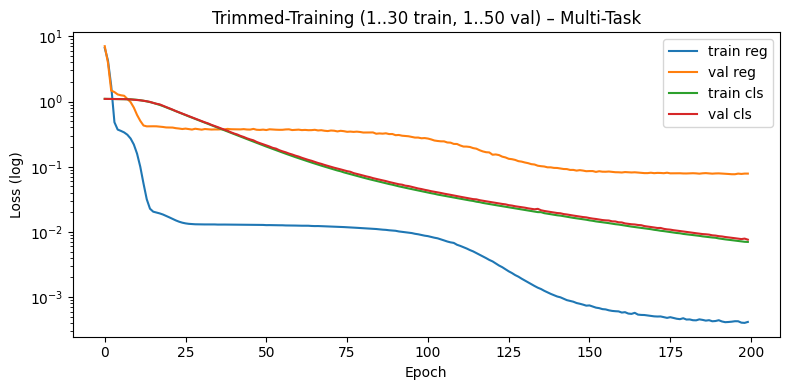

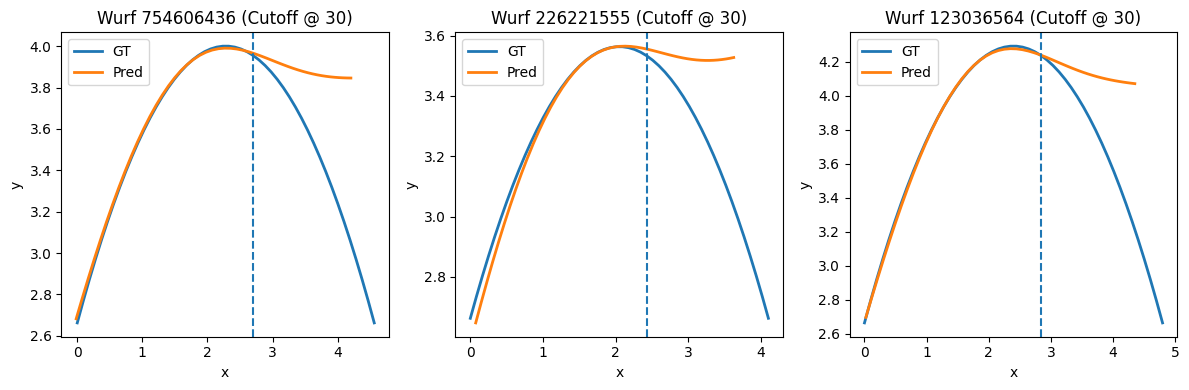

Classification report (throw level):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       150
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       150

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



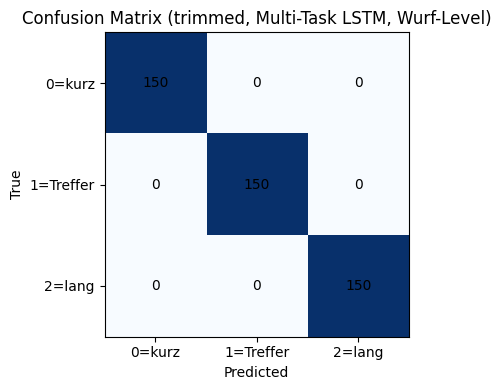

In [35]:
device = "cuda" if torch.cuda.is_available() else "cpu"

sim = DataGen(hs=2.13)
params = (
    sim.params
    if hasattr(sim, "params")
    else {"l": 4.115, "hKorb": 3.048, "Rr": 0.2286, "Rb": 0.1219}
)

df_clean = sim.generate_dataset(n=150, with_noise=False)

# Split: train nur auf Punkten 1..30, aber Evaluation auf 1..50
df_train30, df_full50 = split_first30_full50(df_clean, first_n=30)

model_trim = LSTMxyMultiTask(
    input_size=4, hidden_size=64, num_layers=1, n_classes=3
).to(device)

best_val, hist_trim = train_lstm_trimmed_multitask(
    model_trim,
    df_train30=df_train30,
    df_val_full50=df_full50,
    hs_val=2.13,
    device=device,
    epochs=200,
    batch_size=512,
    lr=1e-3,
    weight_decay=1e-4,
    patience=20,
    clip_grad_norm=1.0,
    lambda_cls=0.5,  # z.B. wie bei dir oben
)

print("Bestes Val (kombinierter Loss):", best_val)

# --- Lossverlauf plotten ---
plt.figure(figsize=(8, 4))
plt.plot(hist_trim["train_reg_loss"], label="train reg")
plt.plot(hist_trim["val_reg_loss"], label="val reg")
plt.plot(hist_trim["train_cls_loss"], label="train cls")
plt.plot(hist_trim["val_cls_loss"], label="val cls")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log)")
plt.title("Trimmed-Training (1..30 train, 1..50 val) – Multi-Task")
plt.legend()
plt.tight_layout()

# --- Vorhersagen auf vollem 1..50-Set ---
pred_full = predict_full_multitask(model_trim, df_full50, hs_val=2.13, device=device)

# --- In-/Out-of-Domain Metriken (Regression) ---
metrics_trim = evaluate_in_out_domain(pred_full, cutoff=30)
print(metrics_trim)

plot_trajectories_with_cutoff(
    pred_full,
    cutoff=30,
    n_examples=3,
    cols=3,
    figsize_all=(6, 5),
    figsize_grid=(12, 4),
)

# --- Wurf-Level-Confusion-Matrix aus Netz-Klassifikation ---
cm_trim = evaluate_throw_level_cls_from_logits(pred_full)

plt.figure(figsize=(5, 4))
plt.imshow(cm_trim, cmap="Blues")
plt.title("Confusion Matrix (trimmed, Multi-Task LSTM, Wurf-Level)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1, 2], ["0=kurz", "1=Treffer", "2=lang"])
plt.yticks([0, 1, 2], ["0=kurz", "1=Treffer", "2=lang"])
for i in range(cm_trim.shape[0]):
    for j in range(cm_trim.shape[1]):
        plt.text(j, i, cm_trim[i, j], ha="center", va="center", color="black")
plt.tight_layout()